## Constructing the synthetic records

Scaled resolved waves, spectral infill, CHAOS, and covariance perturbations.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import h5py
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm, Normalize

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *

plt.rcParams.update({"font.size": 11})

['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
There are 70 knots
There are: 64 splines
There are: 20 degrees


In [3]:
# User choices
mode_numbers = ["62", "6", "13", "48", "45", "1", "32"]
demo_time = 20
nmax = 15

gnm_chaos = CHAOS_Full_SV_Record_Obtain(nmax=nmax)
_, gnm_waves, mode_info = Synthetic_Full_SV_Record_Obtain(
    mode_numbers, times=times_used_relative, scale_flag=True, nmax=nmax
)
gnm_infill = Non_Wave_Spectral_Infill(
    gnm_chaos, gnm_waves, nmax=nmax, dt_sample=dt_sample
)
gnm_infilled = gnm_waves + gnm_infill
records = [gnm_waves, gnm_infilled, gnm_chaos]
record_titles = ["Scaled resolved modes", "Modes + spectral infill", "CHAOS-8.6"]

Full CHAOS-8.6 timespan is: [1997.1 2026.6]


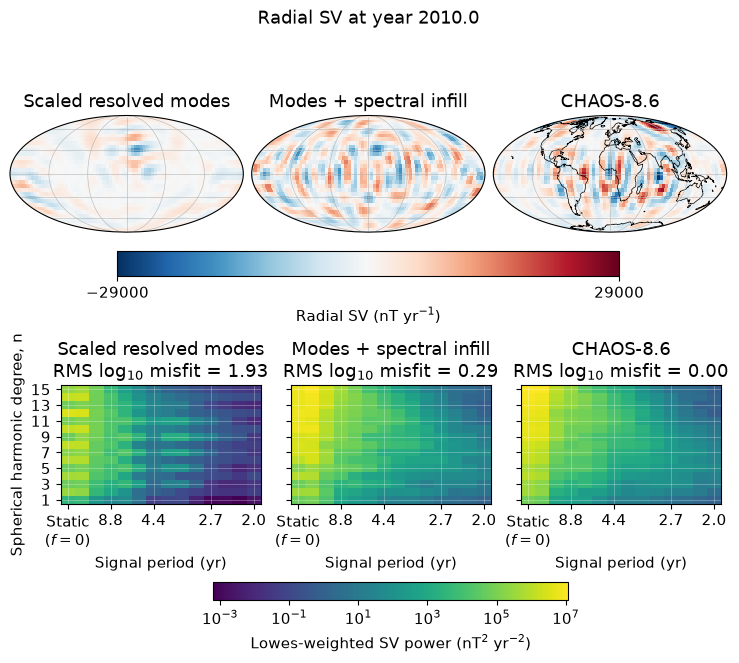

In [4]:
# Radial SV snapshots and Lowes degree-period spectra
fields = [(A_15_r @ record[demo_time]).reshape(state_shape) for record in records]
field_limit = np.ceil(np.max(np.abs(fields)) / 1000) * 1000

spectra = []
for record in records:
    power, spectrum_f = Lowes_Degree_PSD_All_Degrees(
        record, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax
    )
    spectra.append(power)

reliable_f = spectrum_f < 0.5
spectrum_f = spectrum_f[reliable_f]
spectra = [power[:, reliable_f] for power in spectra]
log_misfits = [
    np.sqrt(np.mean((np.log10(power) - np.log10(spectra[-1]))**2))
    for power in spectra
]
positive_power = np.concatenate([power[power > 0] for power in spectra])
power_norm = LogNorm(vmin=positive_power.min(), vmax=positive_power.max())

plot_longitude = (longitude + 180) % 360 - 180
longitude_order = np.argsort(plot_longitude)
longitude_cyclic = np.append(plot_longitude[longitude_order], 180)
frequency_edges = np.arange(len(spectrum_f) + 1)
degree_edges = np.arange(0.5, nmax + 1.5, 1)
tick_bins = np.array([0, 3, 6, 10, len(spectrum_f) - 1])
tick_labels = [
    "Static\n($f=0$)" if index == 0 else f"{1 / spectrum_f[index]:.1f}"
    for index in tick_bins
]

fig = plt.figure(figsize=(text_width, 0.9 * text_width), constrained_layout=True)
map_figure, spectrum_figure = fig.subfigures(2, 1)
map_axes = map_figure.subplots(
    1, 3, subplot_kw={"projection": ccrs.Mollweide()}
)
spectrum_axes = spectrum_figure.subplots(1, 3, sharex=True, sharey=True)

for index, (ax, field, title) in enumerate(zip(map_axes, fields, record_titles)):
    field_sorted = field[:, longitude_order]
    field_cyclic = np.column_stack((field_sorted, field_sorted[:, 0]))
    map_plot = ax.pcolormesh(
        longitude_cyclic, latitude, field_cyclic,
        transform=ccrs.PlateCarree(), cmap="RdBu_r",
        vmin=-field_limit, vmax=field_limit, shading="auto",
    )
    if index == 2:
        ax.coastlines(color="black", linewidth=0.5)
    ax.set_global()
    ax.gridlines(color="0.7", linewidth=0.4)
    ax.set_title(title)

map_cbar = map_figure.colorbar(
    map_plot, ax=map_axes, orientation="horizontal", pad=0.08, shrink=0.7,
    label=r"Radial SV (nT yr$^{-1}$)",
)
map_cbar.set_ticks([-field_limit, field_limit])
map_figure.suptitle(f"Radial SV at year {times_used[demo_time]:.1f}")

for ax, power, title, misfit in zip(
    spectrum_axes, spectra, record_titles, log_misfits
):
    spectrum_plot = ax.pcolormesh(
        frequency_edges, degree_edges, power, cmap="viridis",
        norm=power_norm, shading="flat",
    )
    ax.set(
        title=f"{title}\nRMS log$_{{10}}$ misfit = {misfit:.2f}",
        xlabel="Signal period (yr)",
        xticks=tick_bins + 0.5, xticklabels=tick_labels,
        yticks=np.arange(1, nmax + 1, 2),
    )
    ax.grid(True, color="white", linewidth=0.4, alpha=0.5)

spectrum_axes[0].set_ylabel("Spherical harmonic degree, n")
spectrum_figure.colorbar(
    spectrum_plot, ax=spectrum_axes, orientation="horizontal",
    pad=0.08, shrink=0.7,
    label=r"Lowes-weighted SV power (nT$^2$ yr$^{-2}$)",
)
plt.show()

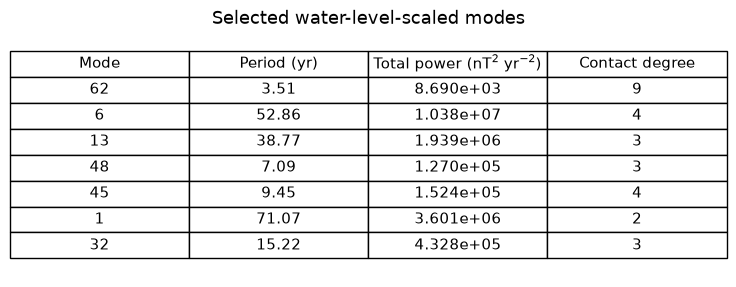

In [5]:
# Period, total scaled power, and water-level contact degree
table_rows = []
for mode_number in mode_numbers:
    mode_spectrum, _ = Lowes_Degree_PSD_All_Degrees(
        mode_info[mode_number]["gnm_resolved"],
        a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax,
    )
    mode_spectrum = mode_spectrum[:, reliable_f]
    contact_degree = np.unravel_index(
        np.argmax(mode_spectrum / spectra[-1]), mode_spectrum.shape
    )[0] + 1
    table_rows.append([
        mode_number,
        f"{mode_info[mode_number]['true_period']:.2f}",
        f"{np.sum(mode_spectrum):.3e}",
        contact_degree,
    ])

fig, ax = plt.subplots(
    figsize=(text_width, 0.38 * text_width), constrained_layout=True
)
ax.axis("off")
mode_table = ax.table(
    cellText=table_rows,
    colLabels=[
        "Mode", "Period (yr)",
        r"Total power (nT$^2$ yr$^{-2}$)", "Contact degree",
    ],
    cellLoc="center", colLoc="center", loc="center",
)
mode_table.auto_set_font_size(False)
mode_table.set_fontsize(11)
mode_table.scale(1, 1.35)
ax.set_title("Selected water-level-scaled modes")
plt.show()

In [6]:
# CHAOS covariance perturbations and their p99 degree-period spectrum
perturbation_path = (
    Path(CHAOS_COV_DIR)
    / "CHAOS_0806_nmax15_SV_nTyr_perturbations_N1000_Nt53.h5"
)
with h5py.File(perturbation_path, "r") as h5_file:
    perturbations = np.asarray(h5_file["perturbations"]).transpose(0, 2, 1)
    perturbation_times = cp.mjd_to_dyear(h5_file["times_mjd2000"][:])

perturbation_spectra = []
for perturbation in perturbations:
    power, perturbation_f = Lowes_Degree_PSD_All_Degrees(
        perturbation, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax
    )
    perturbation_spectra.append(power[:, perturbation_f < 0.5])

p99_perturbation_spectrum = np.percentile(perturbation_spectra, 99, axis=0)
noise_chaos_ratio = p99_perturbation_spectrum / spectra[-1]
log_noise_chaos_ratio = np.log10(noise_chaos_ratio)
perturbation_field = (
    A_15_r @ perturbations[0, demo_time]
).reshape(state_shape)
perturbation_limit = np.ceil(np.max(np.abs(perturbation_field)) / 1000) * 1000

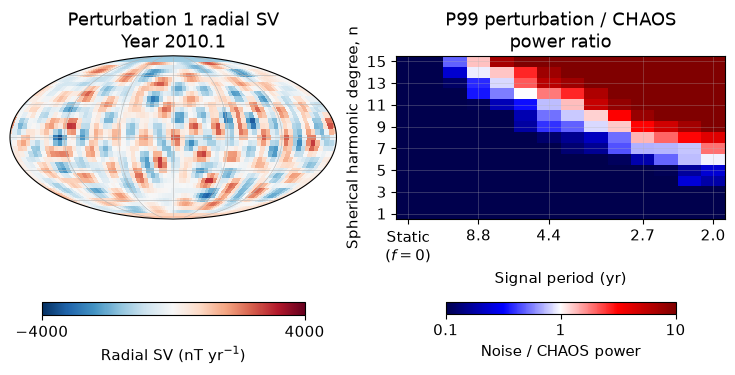

In [7]:
# First perturbation snapshot and the p99 noise-to-CHAOS power ratio
fig = plt.figure(
    figsize=(text_width, 0.5 * text_width), constrained_layout=True
)
grid = fig.add_gridspec(1, 2)
map_ax = fig.add_subplot(grid[0], projection=ccrs.Mollweide())
ratio_ax = fig.add_subplot(grid[1])

field_sorted = perturbation_field[:, longitude_order]
field_cyclic = np.column_stack((field_sorted, field_sorted[:, 0]))
perturbation_plot = map_ax.pcolormesh(
    longitude_cyclic, latitude, field_cyclic, transform=ccrs.PlateCarree(),
    cmap="RdBu_r", vmin=-perturbation_limit, vmax=perturbation_limit,
    shading="auto",
)
map_ax.set_global()
map_ax.gridlines(color="0.7", linewidth=0.4)
map_ax.set_title(
    f"Perturbation 1 radial SV\nYear {perturbation_times[demo_time]:.1f}"
)
map_cbar = fig.colorbar(
    perturbation_plot, ax=map_ax, orientation="horizontal",
    pad=0.08, shrink=0.8, label=r"Radial SV (nT yr$^{-1}$)",
)
map_cbar.set_ticks([-perturbation_limit, perturbation_limit])

ratio_norm = Normalize(vmin=-1, vmax=1, clip=True)
ratio_plot = ratio_ax.pcolormesh(
    frequency_edges, degree_edges, log_noise_chaos_ratio,
    cmap="seismic", norm=ratio_norm, shading="flat",
)
ratio_ax.set(
    title="P99 perturbation / CHAOS\npower ratio",
    xlabel="Signal period (yr)",
    ylabel="Spherical harmonic degree, n",
    xticks=tick_bins + 0.5, xticklabels=tick_labels,
    yticks=np.arange(1, nmax + 1, 2),
)
ratio_ax.grid(True, color="0.7", linewidth=0.4, alpha=0.5)
ratio_cbar = fig.colorbar(
    ratio_plot, ax=ratio_ax, orientation="horizontal",
    pad=0.08, shrink=0.7, label="Noise / CHAOS power",
)
ratio_cbar.set_ticks([-1, 0, 1])
ratio_cbar.set_ticklabels(["0.1", "1", "10"])
plt.show()